# Iris Flower Classification

## Oasis Infobyte Data Science Internship- Task-1

### Objective:
The objective of this project is to build a Machchine Learning model that can accurately classify Iris Flowers into one of three species based on four flower measurements.

### Dataset:
- Total samples : 150
- Features : 4
- Classes : 3
- Problem Type : Multiclass Classification

### Algorithms and Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Importing Required Libraries

In this section, we import all the libraries required for data manipulation, visualization, and machine learning.

- **Pandas** → Data manipulation
- **NumPy** → Numerical computations
- **Matplotlib** → Basic data visualization
- **Seaborn** → Statistical visualization
- **Scikit-learn** → Loading the dataset and building machine learning models

In [2]:
#importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

## Loading the Iris Dataset

The Iris dataset is a built-in dataset available in Scikit-learn.

It contains 150 flower samples with four numerical features and one target variable representing the flower species.

In [3]:
iris = load_iris()

## Understanding the Dataset Object

Before exploring the data, let's check the type of object returned by the `load_iris()` function.

In [4]:
type(iris)

sklearn.utils._bunch.Bunch

### Observation

The `load_iris()` function returns a Bunch object instead of a Pandas DataFrame. This object stores the dataset along with metadata such as feature names, target names, and a description of the dataset.

In [5]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
iris.data.shape

(150, 4)

In [9]:
iris.target.shape

(150,)

## Creating a Pandas DataFrame

The Iris dataset is currently stored as a Scikit-learn Bunch object. For easier exploration and analysis, we convert the feature data into a Pandas DataFrame and assign meaningful column names using the feature names provided by the dataset.

In [10]:
#Create a dataframe

df = pd.DataFrame(iris.data,columns=iris.feature_names)

#Add target column
df["species"] = iris.target_names[iris.target]

## Exploratory Data Analysis (EDA)

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
df.shape

(150, 5)

In [13]:
#Information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [14]:
#Statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
#Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
142,5.8,2.7,5.1,1.9,virginica


In [18]:
df[df.duplicated(keep=False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


**Observation:** The dataset contains one duplicate row. Since the Iris dataset is a standard benchmark dataset and the duplicate has negligible impact, we will keep all 150 samples for this project.

In [19]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Data Visualization

#### Histogram

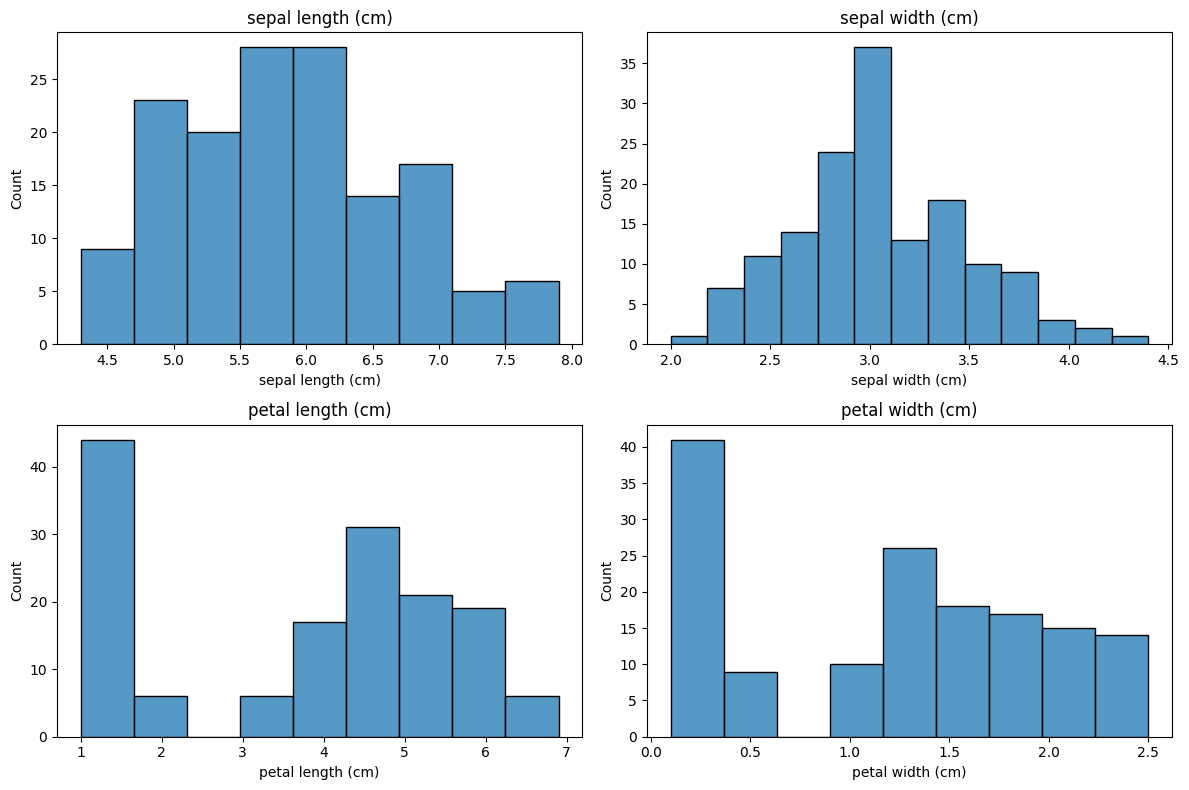

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.histplot(data=df, x=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
# bins=8        #with this we can determine how many bars should be there
plt.show()

#### Boxplot

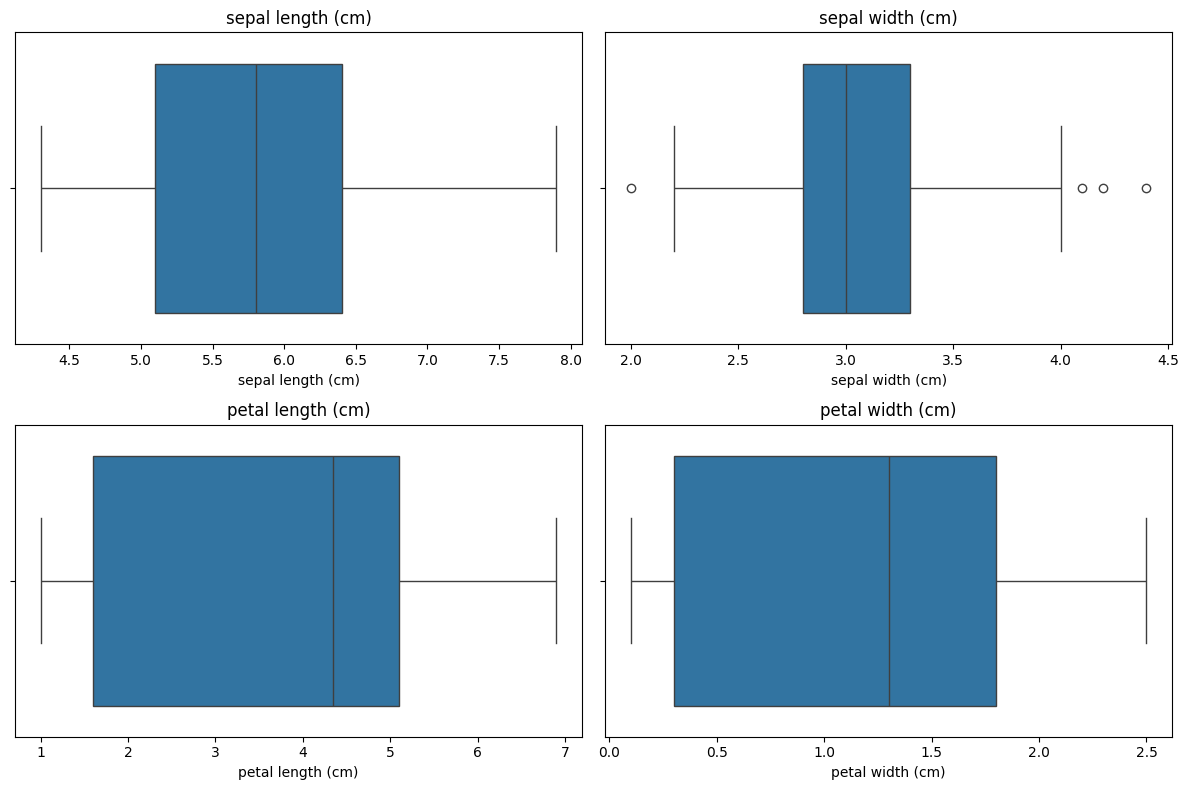

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]
for index, feature in enumerate(features):
    ax = axes[index//2, index%2]
    sns.boxplot(data=df, x=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

#### Scatter Plot

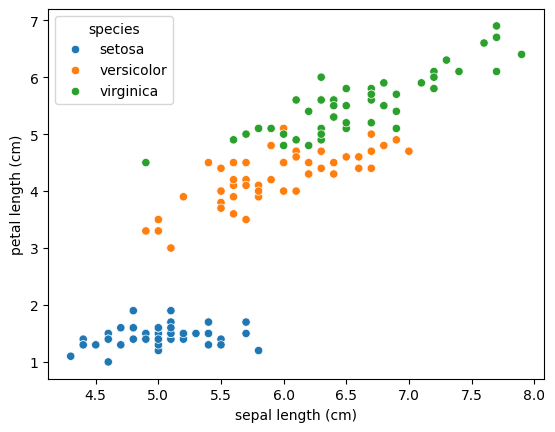

In [22]:
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="species"
)

plt.show()

#### Pair Plot

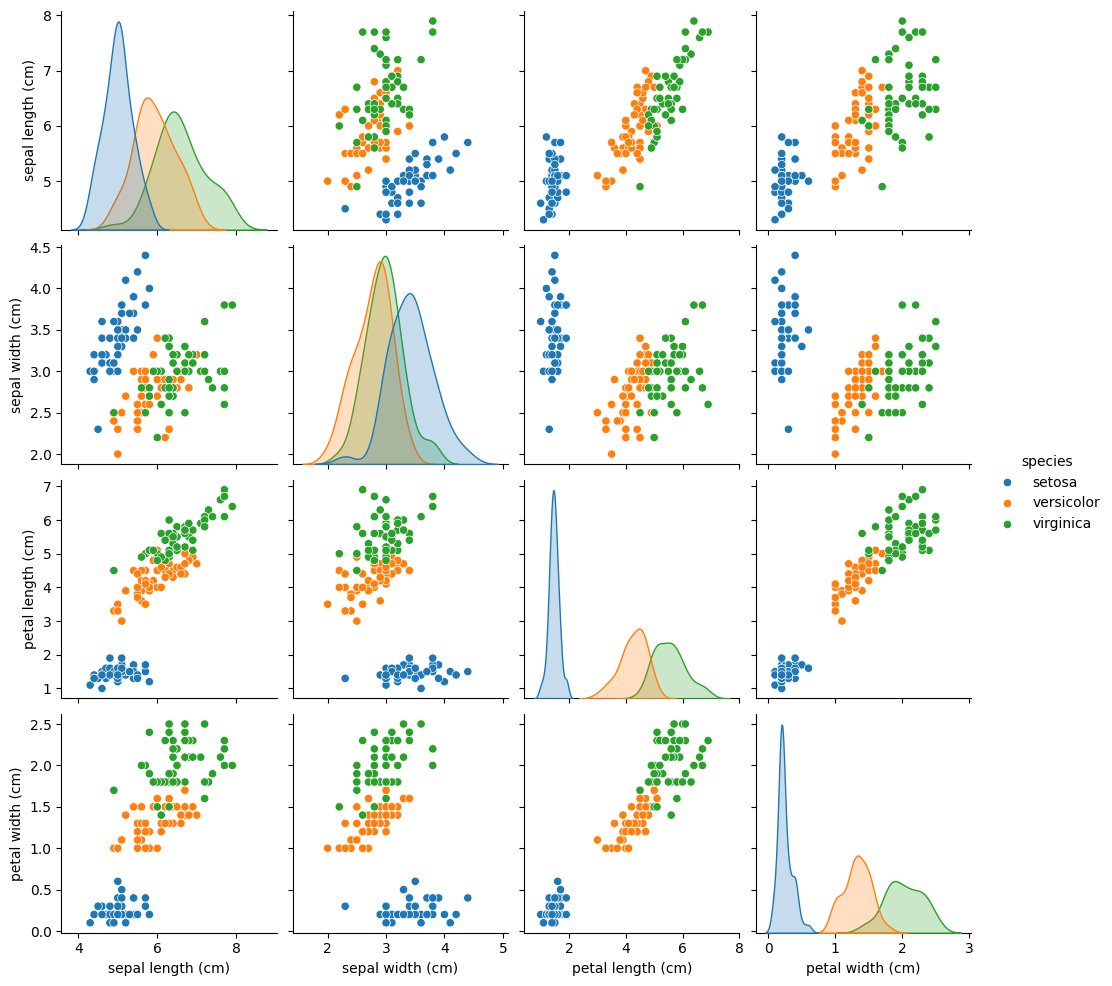

In [23]:
sns.pairplot(
    data=df,
    hue="species"
)

plt.show()

## Machine Learning

### Feature Selection

In [24]:
X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

y = df["species"]

In [25]:
X.shape

(150, 4)

In [26]:
y.shape

(150,)

### Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
X_train.shape

(120, 4)

In [29]:
X_test.shape

(30, 4)

In [30]:
y_train.shape

(120,)

In [31]:
y_test.shape

(30,)

### K-Nearest Neighbors (KNN)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

In [33]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Model Evaluation

#### Accuracy

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


#### Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [38]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

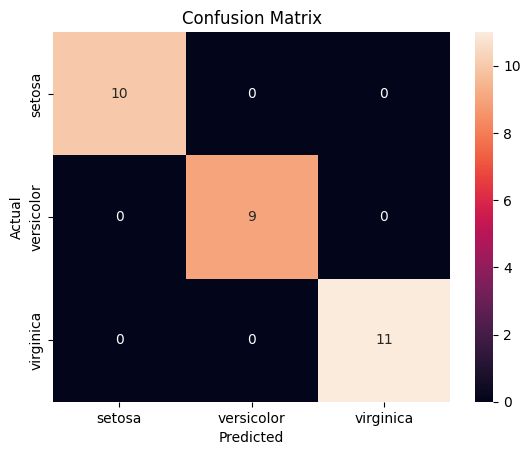

In [39]:
sns.heatmap(
    cm,
    annot=True,
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### Classification Report

In [40]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### KNN Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11]
}

In [42]:
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherval

In [43]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

Best Parameters: {'n_neighbors': 3}
Best Cross-Validation Score: 95.83%


In [44]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Original KNN Accuracy (K=5): {accuracy * 100:.2f}%")
print(f"Tuned KNN Accuracy (K=3): {tuned_accuracy * 100:.2f}%")
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

Original KNN Accuracy (K=5): 100.00%
Tuned KNN Accuracy (K=3): 100.00%
Best Parameters: {'n_neighbors': 3}
Best Cross-Validation Score: 95.83%


#### Tuning Results

GridSearchCV selected `n_neighbors=3` as the best KNN hyperparameter using 5-fold cross-validation, achieving an average cross-validation accuracy of approximately 95.83%. The tuned KNN model achieved 100% accuracy on the held-out test set, equal to the original KNN model with `K=5`.

### Decision Tree Classifier

In [45]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(random_state=42)

In [46]:
dt_model.fit(X_train, y_train)
dt_y_pred = dt_model.predict(X_test)

In [47]:
dt_accuracy = accuracy_score(y_test, dt_y_pred)

print(f"Accuracy: {dt_accuracy * 100:.2f}%")

Accuracy: 100.00%


#### Decision Tree Visualization

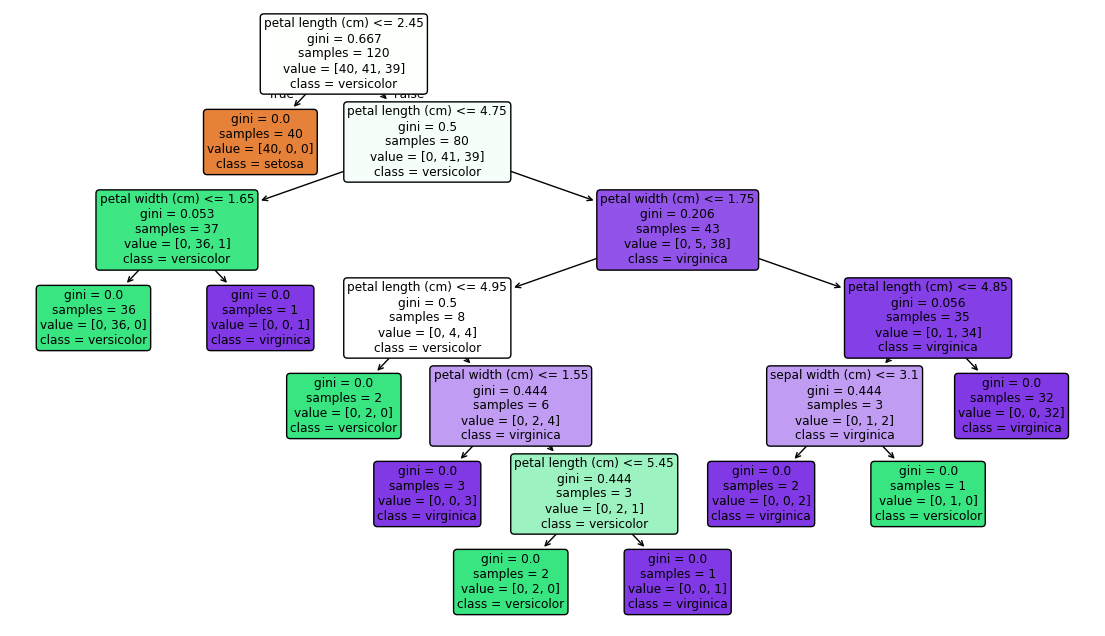

In [48]:
plt.figure(figsize=(14, 8))

plot_tree(
    dt_model,
    feature_names=features,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [49]:
dt_model.feature_importances_

array([0.        , 0.01667014, 0.90614339, 0.07718647])

#### Feature Importance

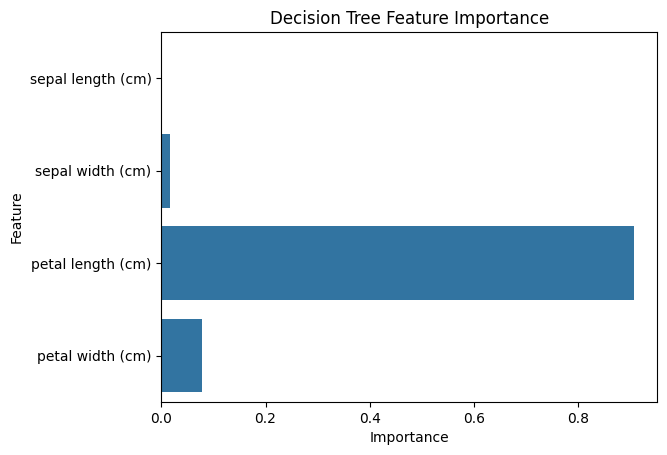

In [50]:
sns.barplot(
    x=dt_model.feature_importances_,
    y=features
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Decision Tree Observations

- The Decision Tree achieved **100% accuracy** on the held-out test set.
- The first split was based on **petal length ≤ 2.45 cm**, showing that petal length plays a major role in separating the Iris species.
- Petal length had the highest feature importance at approximately **90.61%**, followed by petal width at approximately **7.72%**.
- Sepal features contributed very little to this particular fitted Decision Tree.
- These results are consistent with the patterns observed during exploratory data analysis, where petal features provided clearer separation between species.

### Random Forest Classifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [53]:
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

Accuracy: 100.00%


In [54]:
rf_model.feature_importances_

array([0.10809762, 0.03038681, 0.43999397, 0.42152159])

#### Feature Importance

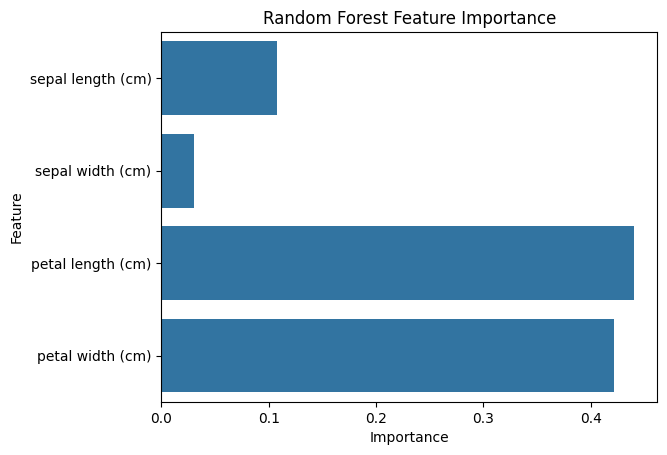

In [55]:
sns.barplot(
    x=rf_model.feature_importances_,
    y=features
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#### Random Forest Observations

- The Random Forest classifier achieved **100% accuracy** on the held-out test set.
- Petal length and petal width were the most influential features, contributing approximately **44.00%** and **42.15%** of the feature importance, respectively.
- Unlike the single Decision Tree, Random Forest distributed importance more evenly across multiple features.
- The results support the exploratory data analysis, where petal measurements showed the clearest separation between Iris species.